Blood Cell Type Prediction
***

## Blood Cell Type Prediction  

Given *images of blood cells*, let's try to predict the **type of cell** present in a given image.

We will use a TensorFlow pretrained CNN model to make our predictions.

# Getting Started

In [1]:
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report

In [2]:
train_dir = '../input/blood-cells/dataset2-master/dataset2-master/images/TRAIN'
test_dir = '../input/blood-cells/dataset2-master/dataset2-master/images/TEST'

# Loading Image Data

In [3]:
# Create generators

train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [4]:
# Flow image data

train_images = train_gen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_gen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_gen.flow_from_directory(
    directory=test_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.


# Build Pretrained Model

In [5]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9412608/9406464 [==============================] - 0s 0us/step


# Build Classification Model

In [6]:
inputs = pretrained_model.input
x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 112, 112, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 112, 112, 32) 128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu (ReLU)               (None, 112, 112, 32) 0           bn_Conv1[0][0]                   
______________________________________________________________________________________________

# Training

In [7]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
249/249 [==============================] - 59s 215ms/step - loss: 1.0170 - accuracy: 0.5796 - val_loss: 0.5576 - val_accuracy: 0.7868
Epoch 2/100
249/249 [==============================] - 28s 111ms/step - loss: 0.4883 - accuracy: 0.8135 - val_loss: 0.4270 - val_accuracy: 0.8306
Epoch 3/100
249/249 [==============================] - 28s 112ms/step - loss: 0.3444 - accuracy: 0.8778 - val_loss: 0.4095 - val_accuracy: 0.8291
Epoch 4/100
249/249 [==============================] - 28s 113ms/step - loss: 0.2779 - accuracy: 0.8962 - val_loss: 0.2969 - val_accuracy: 0.8924
Epoch 5/100
249/249 [==============================] - 27s 110ms/step - loss: 0.2180 - accuracy: 0.9279 - val_loss: 0.3325 - val_accuracy: 0.8643
Epoch 6/100
249/249 [==============================] - 27s 107ms/step - loss: 0.1729 - accuracy: 0.9420 - val_loss: 0.2709 - val_accuracy: 0.8979
Epoch 7/100
249/249 [==============================] - 27s 110ms/step - loss: 0.1373 - accuracy: 0.9563 - val_loss: 0.2327 -

In [8]:
fig = px.line(
    history.history,
    y=['loss', 'val_loss'],
    labels={'index': "Epoch", 'value': "Loss"},
    title="Training and Validation Loss Over Time"
)

fig.show()

# Results

In [9]:
CLASS_NAMES = list(train_images.class_indices.keys())
CLASS_NAMES

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

Test Accuracy: 52.955%


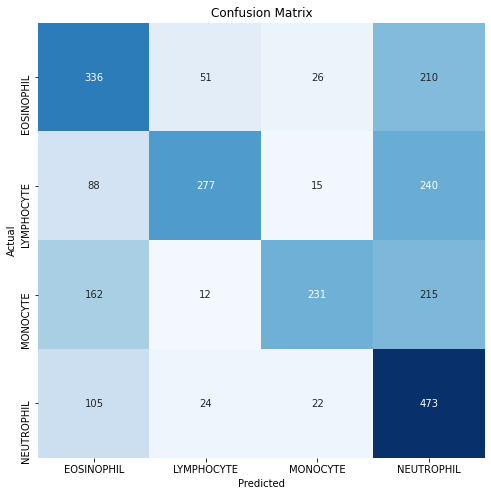

Classification Report:
----------------------
               precision    recall  f1-score   support

  EOSINOPHIL       0.49      0.54      0.51       623
  LYMPHOCYTE       0.76      0.45      0.56       620
    MONOCYTE       0.79      0.37      0.51       620
  NEUTROPHIL       0.42      0.76      0.54       624

    accuracy                           0.53      2487
   macro avg       0.61      0.53      0.53      2487
weighted avg       0.61      0.53      0.53      2487



In [10]:
predictions = np.argmax(model.predict(test_images), axis=1)

acc = accuracy_score(test_images.labels, predictions)
cm = tf.math.confusion_matrix(test_images.labels, predictions)
clr = classification_report(test_images.labels, predictions, target_names=CLASS_NAMES)

print("Test Accuracy: {:.3f}%".format(acc * 100))

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
plt.xticks(ticks= np.arange(4) + 0.5, labels=CLASS_NAMES)
plt.yticks(ticks= np.arange(4) + 0.5, labels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n----------------------\n", clr)

Found 1989 images belonging to 4 classes.
Validation Accuracy: 94.419%


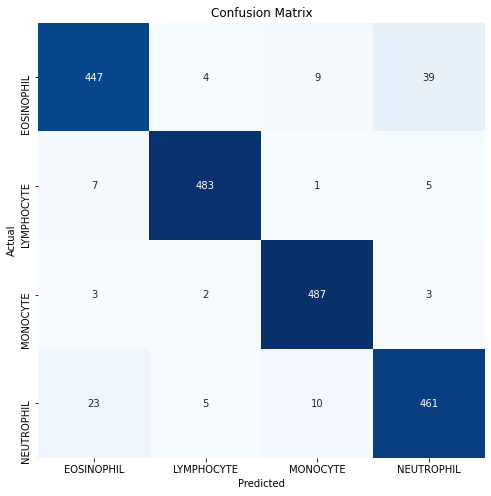

Classification Report:
----------------------
               precision    recall  f1-score   support

  EOSINOPHIL       0.93      0.90      0.91       499
  LYMPHOCYTE       0.98      0.97      0.98       496
    MONOCYTE       0.96      0.98      0.97       495
  NEUTROPHIL       0.91      0.92      0.92       499

    accuracy                           0.94      1989
   macro avg       0.94      0.94      0.94      1989
weighted avg       0.94      0.94      0.94      1989



In [11]:
val_images = train_gen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42,
    subset='validation'
)


predictions = np.argmax(model.predict(val_images), axis=1)

acc = accuracy_score(val_images.labels, predictions)
cm = tf.math.confusion_matrix(val_images.labels, predictions)
clr = classification_report(val_images.labels, predictions, target_names=CLASS_NAMES)

print("Validation Accuracy: {:.3f}%".format(acc * 100))

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
plt.xticks(ticks= np.arange(4) + 0.5, labels=CLASS_NAMES)
plt.yticks(ticks= np.arange(4) + 0.5, labels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n----------------------\n", clr)